##Data Source

The dataset used in this project is obtained from Kaggle, titled "AI and Data Science Job Market 2025–2026".

##Motivation

With the rapid growth of AI-related jobs, understanding the factors that influence salaries has become increasingly important for both job seekers and employers.

This project analyzes the AI and Data Science job market to understand which factors influence salary levels. The analysis includes exploratory data analysis (EDA) and hypothesis testing.

## Research Question

This project aims to answer the following questions:

- Does experience level significantly affect salary?
- Does work type (remote, hybrid, onsite) impact salary?
- How are salaries distributed across different roles and company types?

In this section, the dataset is loaded and basic information about the data is examined.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
import pandas as pd

df = pd.read_csv("AI_Job_Market_Trends_2026.csv")

df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


##Data Structure

The dataset contains 10,345 observations and 19 variables, including both categorical and numerical features such as job title, company size, experience level, skills, and salary.

All variables have complete entries with no missing values, making the dataset suitable for statistical analysis without requiring data cleaning.

Categorical variables include job_title, company_size, remote_type, and experience_level, while numerical variables include salary, years_experience, and skill indicators.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

##Summary Statistics

The summary statistics indicate that the average salary is approximately 113,000, with a wide range from around 45,000 to over 200,000.

The standard deviation is relatively high, suggesting substantial variability in salaries across different roles and experience levels.

Additionally, years of experience range from 0 to 14, indicating that the dataset includes both entry-level and highly experienced professionals.

In [9]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


##Salary Distribution

This section examines how salary values are distributed across the dataset.

This skewness suggests that while most employees earn moderate salaries, a smaller group earns significantly higher wages, which may correspond to senior roles or specialized positions.

The histogram shows that salaries are concentrated around the average range, with a slight right-skewed distribution. This indicates that while most salaries fall within a common range, there are some higher-paying positions that create a longer tail on the right side.

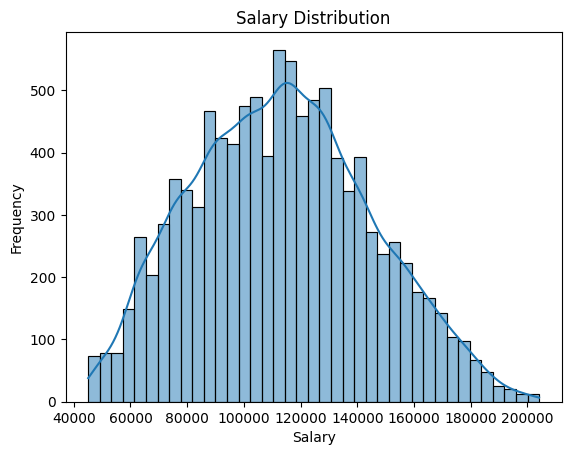

In [10]:
sns.histplot(df["salary"], kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

The boxplot shows that salary levels increase with experience level. Senior employees have the highest median salary, followed by mid-level and entry-level employees. This suggests a positive relationship between experience and salary.

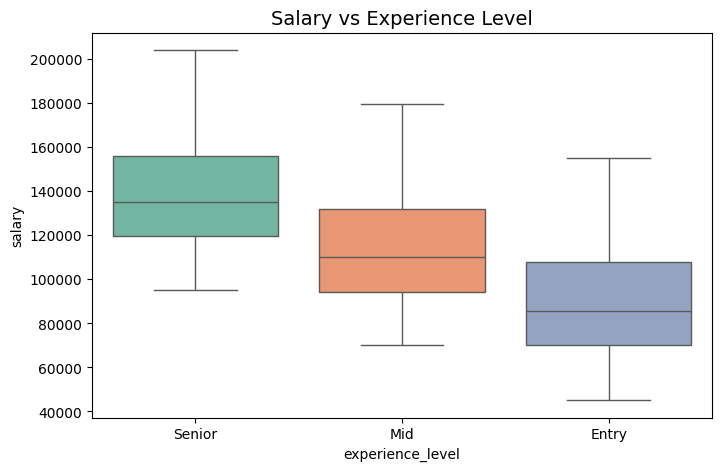

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="experience_level",
    y="salary",
    hue="experience_level",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Salary vs Experience Level", fontsize=14)

plt.show()

##Hypothesis Testing: Experience Level and Salary

To statistically test whether experience level has a significant effect on salary, a one-way ANOVA test is conducted.

H0: There is no difference in salary across experience levels.  
H1: At least one group has a different mean salary.

The high p-value indicates that there is no statistically significant difference between remote and onsite salaries. This reinforces the idea that work type does not independently influence salary levels.

In [22]:
from scipy.stats import f_oneway

entry_salary = df[df["experience_level"] == "Entry"]["salary"]
mid_salary = df[df["experience_level"] == "Mid"]["salary"]
senior_salary = df[df["experience_level"] == "Senior"]["salary"]

f_stat, p_value = f_oneway(entry_salary, mid_salary, senior_salary)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 3615.563899199659
p-value: 0.0


The ANOVA test shows that there is a statistically significant difference in salary across experience levels (p < 0.05).

While experience level shows a strong and statistically significant effect on salary, it is also important to examine whether other factors, such as work type (remote, hybrid, onsite), contribute to salary differences.

Salary vs Work Type

This section examines how salary differs across remote, hybrid, and onsite jobs.

This suggests that remote work alone is not a strong determinant of salary and that companies may offer similar compensation regardless of work arrangement.

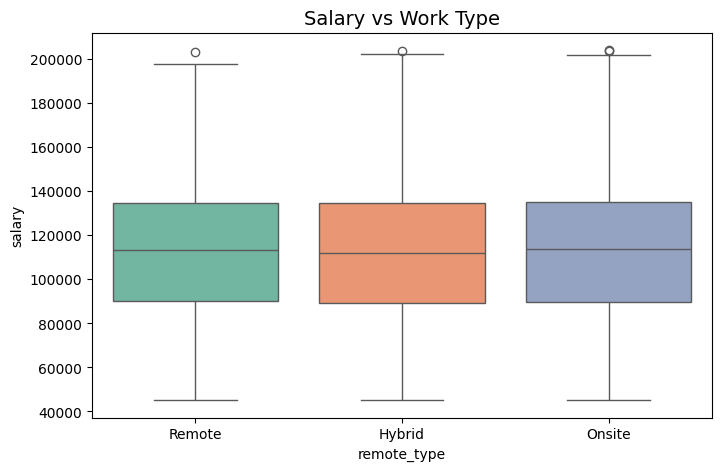

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="remote_type",
    y="salary",
    hue="remote_type",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Salary vs Work Type", fontsize=14)

plt.show()

##Average Salary by Work Type

This chart shows the average salary for each work type to better compare overall differences.

The bar chart shows that the average salaries across remote, hybrid, and onsite roles are quite similar. This indicates that work type alone may not be a strong determinant of salary. Therefore, other factors such as experience level or skills may play a more significant role in explaining salary differences.

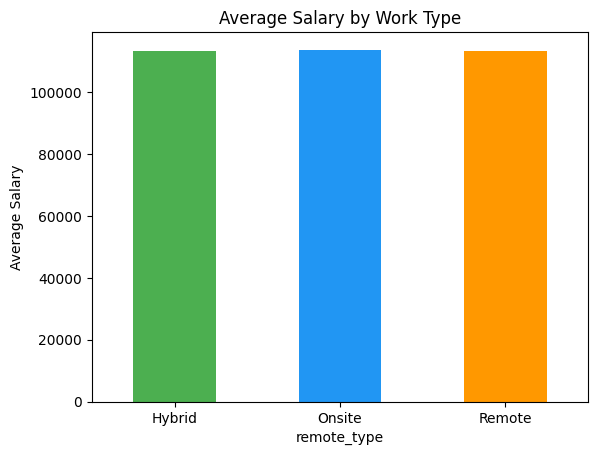

In [14]:
df.groupby("remote_type")["salary"].mean().plot(
    kind="bar",
    color=["#4CAF50", "#2196F3", "#FF9800"]
)

plt.title("Average Salary by Work Type")
plt.ylabel("Average Salary")
plt.xticks(rotation=0)
plt.show()

This observation is consistent with the hypothesis test results, which showed no statistically significant difference between remote and onsite salaries.

The t-test results show that there is no statistically significant difference between remote and onsite salaries (p ≥ 0.05). Therefore, we fail to reject the null hypothesis. This suggests that work type does not have a significant effect on salary.

In [15]:
from scipy.stats import ttest_ind

remote = df[df["remote_type"] == "Remote"]["salary"]
onsite = df[df["remote_type"] == "Onsite"]["salary"]

t_stat, p_value = ttest_ind(remote, onsite)

print("t:", t_stat)
print("p:", p_value)

t: -0.4601814836883942
p: 0.6454004128723607


##EDA: Dataset Overview

This section explores the distribution of job titles, company sizes, and countries in the dataset to better understand its structure.

### Job Title Distribution

This section analyzes the most common job titles in the dataset.
Understanding job title distribution helps identify which roles are most in demand in the AI and Data Science job market.

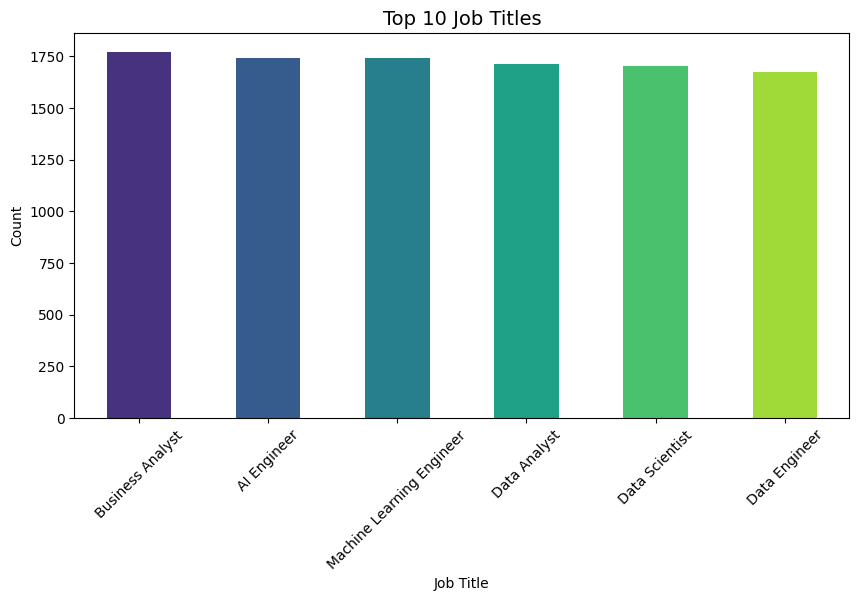

In [24]:
plt.figure(figsize=(10,5))

df['job_title'].value_counts().head(10).plot(
    kind='bar',
    color=sns.color_palette("viridis")
)

plt.title("Top 10 Job Titles", fontsize=14)
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Company Size Distribution

This section examines how job postings are distributed across different company sizes.
It provides insight into which types of companies are more active in hiring.

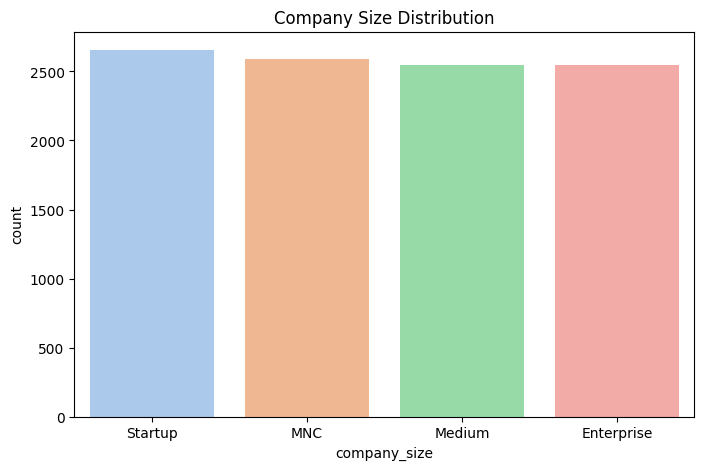

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="company_size",
    hue="company_size",
    data=df,
    palette="pastel",
    legend=False
)
plt.title("Company Size Distribution")

plt.show()

### Country Distribution

This section explores the geographical distribution of job postings.
It helps identify which countries have the highest demand for AI and Data Science roles.

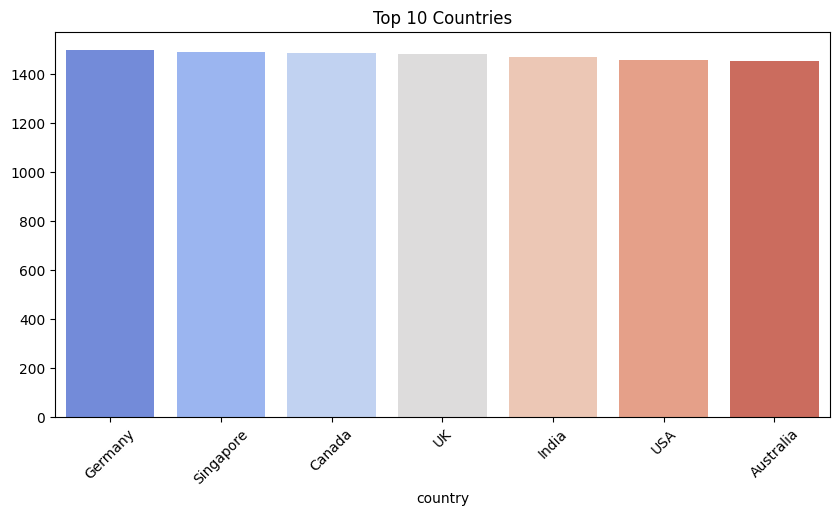

In [29]:
plt.figure(figsize=(10,5))

top_countries = df['country'].value_counts().head(10)

sns.barplot(
    x=top_countries.index,
    y=top_countries.values,
    hue=top_countries.index,
    palette="coolwarm",
    legend=False
)

plt.title("Top 10 Countries")
plt.xticks(rotation=45)

plt.show()

### Salary vs Company Size

This section investigates whether company size has an impact on salary levels.
It allows us to compare salary distributions across different company sizes.

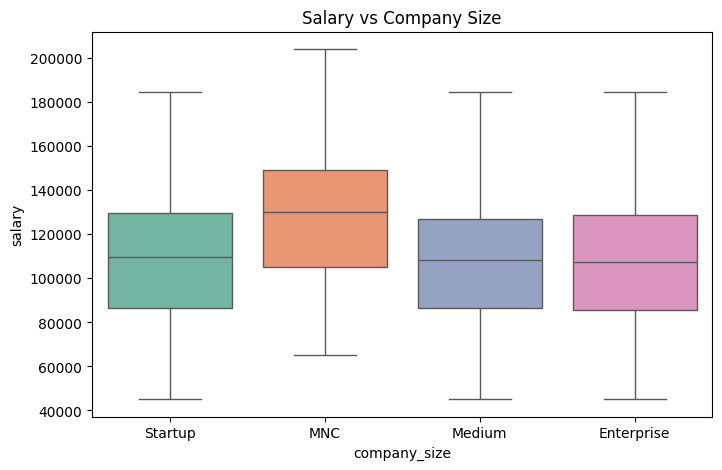

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="company_size",
    y="salary",
    hue="company_size",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Salary vs Company Size")

plt.show()

## Conclusion

This project analyzed the key factors affecting salaries in the AI and Data Science job market.

The findings clearly show that experience level is a strong and statistically significant determinant of salary. As experience increases, salary levels also increase, which is supported by both visual analysis and hypothesis testing results.

In contrast, work type (remote, hybrid, or onsite) does not have a statistically significant impact on salary. This suggests that companies tend to offer similar compensation regardless of work arrangement.

Overall, the results indicate that experience plays a more critical role in determining salary compared to work structure. These findings highlight the importance of human capital factors in salary formation.

These findings are consistent with general expectations in the job market.

## Limitations and Future Work

This analysis is based on a single dataset and may not fully capture all factors influencing salaries in the AI and Data Science job market.

Important variables such as industry, company size, and specific technical skills were not deeply analyzed in this study. Future work could incorporate these factors to provide a more comprehensive understanding of salary differences.

Additionally, applying machine learning models could help predict salary levels more accurately and reveal more complex relationships between variables.